<a href="https://colab.research.google.com/github/hecfrantuis/Proyecto-IA-1/blob/main/Proyecto_AcneI_A1_Modelos_Supervisados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Drive - Librerias

In [9]:
#@title Montar el drive
import os
from google.colab import drive

Ubicacion = "Septimo/IA 1 2026-1/Proyecto/AcneDataset/train" #@param {type:"string"}
path = "/content/drive/My Drive/" + Ubicacion
drive.mount('/content/drive')
os.chdir(path)
print(os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive/Septimo/IA 1 2026-1/Proyecto/AcneDataset/train


In [10]:
# @title Librerias
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern
from scipy.stats import zscore, entropy, stats
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.feature_selection import SelectKBest, f_classif

# Seleccion de datos

In [11]:
# @title DataFrame con etiquetas
data = []

for etiqueta in os.listdir('.'):
    if os.path.isdir(etiqueta):
        for archivo in os.listdir(etiqueta):
            if archivo.endswith(('.jpg', '.png')):
                ruta_completa = os.path.join(etiqueta, archivo)
                img_bgr = cv2.imread(ruta_completa)

                if img_bgr is None:
                    continue

                # ── RGB ──────────────────────────────────────────────
                rojo   = np.mean(img_bgr[:, :, 2])
                verde  = np.mean(img_bgr[:, :, 1])
                azul   = np.mean(img_bgr[:, :, 0])
                contraste = img_bgr.std()

                # ── HSV (detecta inflamación y saturación) ────────────
                img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
                hue_mean = np.mean(img_hsv[:, :, 0])
                sat_mean = np.mean(img_hsv[:, :, 1])
                val_mean = np.mean(img_hsv[:, :, 2])

                # ── LBP — Local Binary Patterns (textura) ─────────────
                gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
                lbp  = local_binary_pattern(gris, P=8, R=1, method='uniform')
                lbp_hist, _ = np.histogram(lbp.ravel(),
                                           bins=np.arange(0, 11),
                                           density=True)
                lbp_mean = np.mean(lbp)

                # ── Entropía (rugosidad / complejidad visual) ──────────
                # Histograma de la imagen en escala de grises → entropía
                hist_gris, _ = np.histogram(gris.ravel(), bins=256,
                                            range=(0, 256), density=True)
                hist_gris += 1e-10          # evitar log(0)
                entropia = entropy(hist_gris)

                data.append({
                    'Etiqueta'  : etiqueta,
                    'Rojo'      : rojo,
                    'Verde'     : verde,
                    'Azul'      : azul,
                    'Contraste' : contraste,
                    'Hue'       : hue_mean,
                    'Saturacion': sat_mean,
                    'Valor_HSV' : val_mean,
                    'LBP_Mean'  : lbp_mean,
                    'Entropia'  : entropia,
                })

df_proyecto = pd.DataFrame(data)
print(f"Dataset inicial: {df_proyecto.shape}")
print(df_proyecto['Etiqueta'].value_counts())

Dataset inicial: (2778, 10)
Etiqueta
Blackheads    735
Cyst          645
Papules       621
Pustules      584
Whiteheads    193
Name: count, dtype: int64


Dimensiones: X_scaled=(2778, 9) | y=(2778,)

Ranking de características:
   Feature    F_Score       P_Value
  Entropia 188.469600 4.638511e-143
 Valor_HSV 105.286800  1.337387e-83
      Rojo 103.745579  1.923212e-82
  LBP_Mean  89.618778  9.940607e-72
     Verde  74.602064  3.882311e-60
      Azul  70.574123  5.425725e-57
Saturacion  55.898714  2.109416e-45
 Contraste  22.571546  2.277749e-18
       Hue  21.193754  3.102531e-17


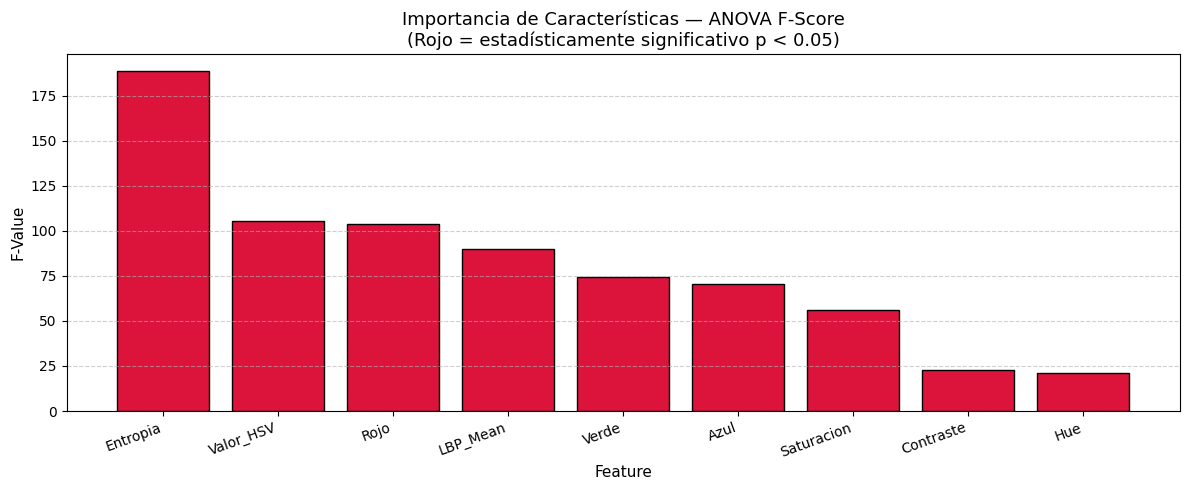

In [12]:
# @title Seleccion de las caracteristicas mas importantes
# Etiquetas
le = LabelEncoder()
df_proyecto['Etiqueta_Num'] = le.fit_transform(df_proyecto['Etiqueta'])

columnas_numericas = ['Rojo', 'Verde', 'Azul', 'Contraste',
                      'Hue', 'Saturacion', 'Valor_HSV', 'LBP_Mean', 'Entropia']

# Separamos X y y SIEMPRE desde df_proyecto
X = df_proyecto[columnas_numericas]          # features
y = df_proyecto['Etiqueta_Num']              # target (numérico)

# Escalamiento con RobustScaler (más robusto ante los outliers residuales)
scaler   = RobustScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dimensiones: X_scaled={X_scaled.shape} | y={y.shape}")
# ▲ Deben coincidir — este era tu error: antes usabas 'y' (df_proyecto) en vez de y

# ── SelectKBest con ANOVA ─────────────────────────────────────────────────────
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_scaled, y)          # ← y, NO y

# ── Visualización de importancia ──────────────────────────────────────────────
scores_df = pd.DataFrame({
    'Feature': columnas_numericas,
    'F_Score': selector.scores_,
    'P_Value': selector.pvalues_
}).sort_values('F_Score', ascending=False)

print("\nRanking de características:")
print(scores_df.to_string(index=False))

plt.figure(figsize=(12, 5))
colores = ['crimson' if p < 0.05 else 'steelblue'
           for p in scores_df['P_Value']]
plt.bar(scores_df['Feature'], scores_df['F_Score'],
        color=colores, edgecolor='black')
plt.title("Importancia de Características — ANOVA F-Score\n"
          "(Rojo = estadísticamente significativo p < 0.05)", fontsize=13)
plt.xlabel("Feature", fontsize=11)
plt.ylabel("F-Value", fontsize=11)
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── Seleccionamos las K mejores (ej. k=5) para el modelo final ────────────────
K_MEJOR = 5
selector_k = SelectKBest(score_func=f_classif, k=K_MEJOR)
X_final    = selector_k.fit_transform(X_scaled, y)
features_seleccionadas = np.array(columnas_numericas)[selector_k.get_support()]

# Prueba con Modelos

In [13]:
print("X original:", X.shape)
print("X_scaled:", X_scaled.shape)
print("X_final:", X_final.shape)
print("y:", y.shape)
print("Features seleccionadas:", features_seleccionadas)

X original: (2778, 9)
X_scaled: (2778, 9)
X_final: (2778, 5)
y: (2778,)
Features seleccionadas: ['Rojo' 'Verde' 'Valor_HSV' 'LBP_Mean' 'Entropia']


In [ ]:
#Naive bayes:

In [14]:
# @title Modelo Naive Bayes con las características seleccionadas

import numpy as np
import joblib
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

# Usamos directamente las variables del primer bloque
# X_final = características seleccionadas con SelectKBest
# y = etiquetas numéricas

X = X_final

# Si y viene como Series de pandas, la pasamos a numpy
y = np.array(y)

# Validación cruzada estratificada
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("Clases:", le.classes_)

Shape de X: (2778, 5)
Shape de y: (2778,)
Clases: ['Blackheads' 'Cyst' 'Papules' 'Pustules' 'Whiteheads']


In [15]:
acc_scores = []
bacc_scores = []

y_true_total = []
y_pred_total = []

fold = 1

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model = GaussianNB()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    bacc = balanced_accuracy_score(y_test, y_pred)

    acc_scores.append(acc)
    bacc_scores.append(bacc)

    y_true_total.extend(y_test)
    y_pred_total.extend(y_pred)

    print(f"Fold {fold}")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Balanced Accuracy: {bacc:.4f}")
    print("-" * 35)

    fold += 1

Fold 1
  Accuracy: 0.3507
  Balanced Accuracy: 0.3646
-----------------------------------
Fold 2
  Accuracy: 0.3453
  Balanced Accuracy: 0.3483
-----------------------------------
Fold 3
  Accuracy: 0.3579
  Balanced Accuracy: 0.3392
-----------------------------------
Fold 4
  Accuracy: 0.4036
  Balanced Accuracy: 0.3837
-----------------------------------
Fold 5
  Accuracy: 0.3640
  Balanced Accuracy: 0.3701
-----------------------------------


In [16]:
print("Resultados globales - Gaussian Naive Bayes")
print(f"Accuracy promedio: {np.mean(acc_scores):.4f}")
print(f"Desviación estándar Accuracy: {np.std(acc_scores):.4f}")
print(f"Balanced Accuracy promedio: {np.mean(bacc_scores):.4f}")
print(f"Desviación estándar Balanced Accuracy: {np.std(bacc_scores):.4f}")

Resultados globales - Gaussian Naive Bayes
Accuracy promedio: 0.3643
Desviación estándar Accuracy: 0.0206
Balanced Accuracy promedio: 0.3612
Desviación estándar Balanced Accuracy: 0.0158


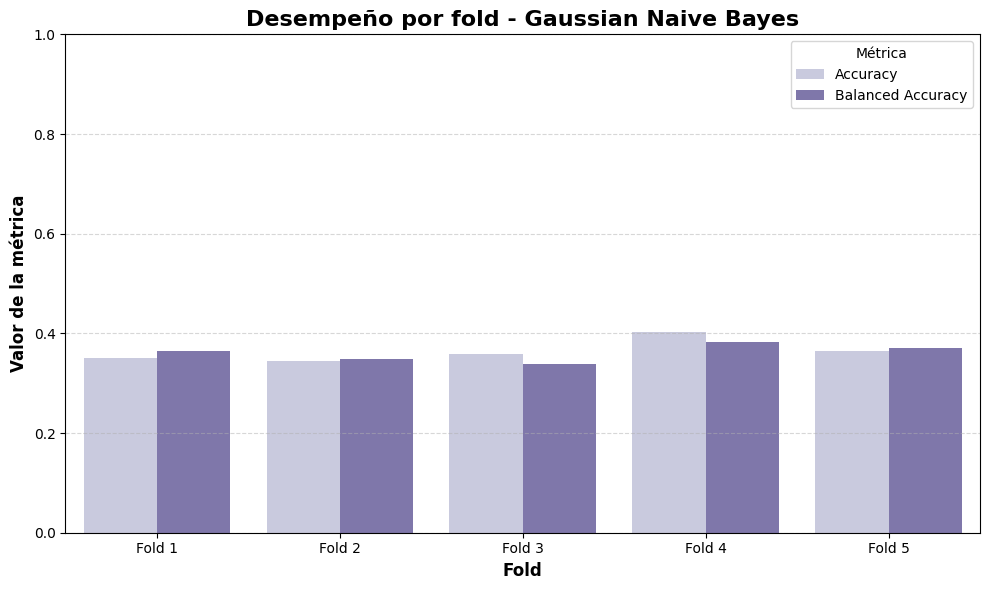

In [17]:
# title Gráfica de desempeño por fold - Gaussian Naive Bayes

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_scores = pd.DataFrame({
    "Fold": [f"Fold {i}" for i in range(1, len(acc_scores) + 1)],
    "Accuracy": acc_scores,
    "Balanced Accuracy": bacc_scores
})

df_scores_plot = df_scores.melt(
    id_vars="Fold",
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_scores_plot,
    x="Fold",
    y="Valor",
    hue="Métrica",
    palette="Purples"
)

plt.title("Desempeño por fold - Gaussian Naive Bayes", fontsize=16, fontweight="bold")
plt.xlabel("Fold", fontsize=12, fontweight="bold")
plt.ylabel("Valor de la métrica", fontsize=12, fontweight="bold")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [18]:
print("Classification Report - Gaussian Naive Bayes")
print(classification_report(y_true_total, y_pred_total, target_names=le.classes_))

Classification Report - Gaussian Naive Bayes
              precision    recall  f1-score   support

  Blackheads       0.33      0.43      0.37       735
        Cyst       0.36      0.63      0.46       645
     Papules       0.40      0.14      0.21       621
    Pustules       0.41      0.21      0.27       584
  Whiteheads       0.47      0.39      0.42       193

    accuracy                           0.36      2778
   macro avg       0.39      0.36      0.35      2778
weighted avg       0.38      0.36      0.34      2778



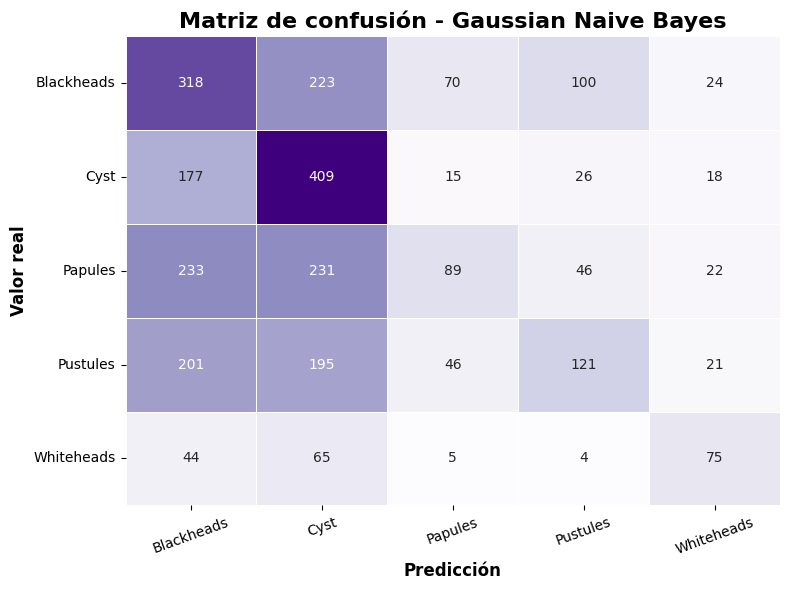

In [19]:
cm = confusion_matrix(y_true_total, y_pred_total)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Purples", cbar=False, linewidths=0.5)
plt.title("Matriz de confusión - Gaussian Naive Bayes", fontsize=16, fontweight="bold")
plt.xlabel("Predicción", fontsize=12, fontweight="bold")
plt.ylabel("Valor real", fontsize=12, fontweight="bold")
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

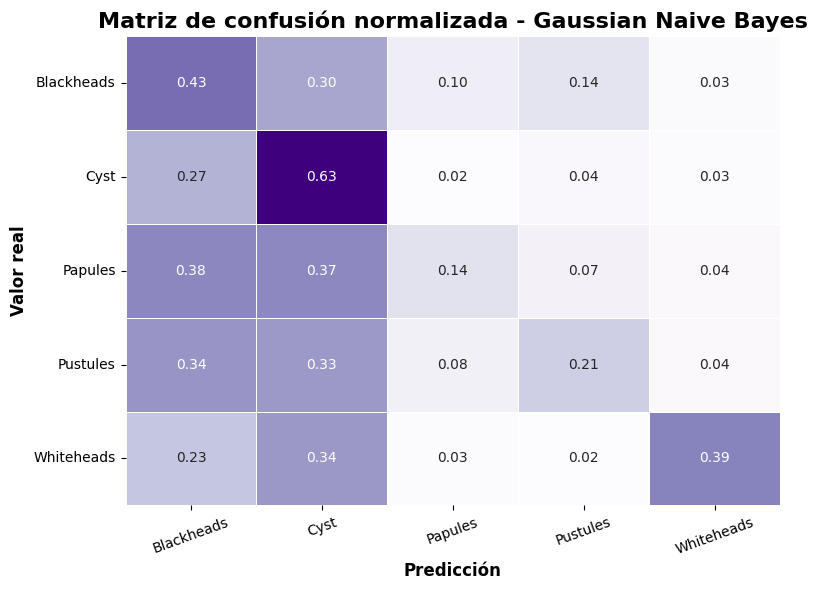

In [20]:
cm_norm = confusion_matrix(y_true_total, y_pred_total, normalize="true")
cm_norm_df = pd.DataFrame(cm_norm, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Purples", cbar=False, linewidths=0.5)
plt.title("Matriz de confusión normalizada - Gaussian Naive Bayes", fontsize=16, fontweight="bold")
plt.xlabel("Predicción", fontsize=12, fontweight="bold")
plt.ylabel("Valor real", fontsize=12, fontweight="bold")
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

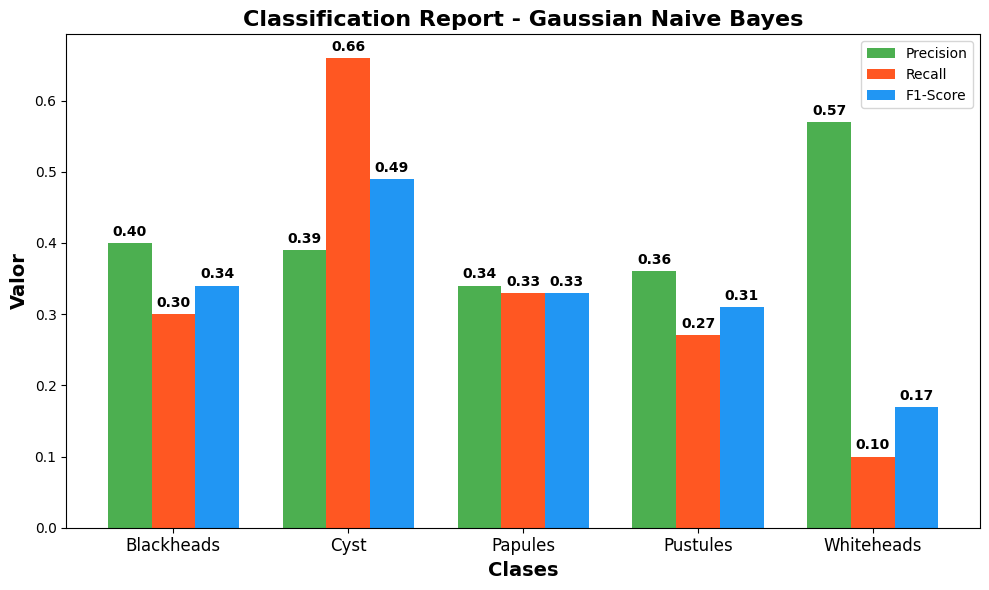

In [21]:
# Datos del classification report
clases = ['Blackheads', 'Cyst', 'Papules', 'Pustules', 'Whiteheads']
precision = [0.40, 0.39, 0.34, 0.36, 0.57]
recall = [0.30, 0.66, 0.33, 0.27, 0.10]
f1_score = [0.34, 0.49, 0.33, 0.31, 0.17]

# Crear gráfico de barras
x = np.arange(len(clases))  # Las posiciones de las clases
width = 0.25  # El ancho de las barras

fig, ax = plt.subplots(figsize=(10, 6))

# Crear las barras para las tres métricas
rects1 = ax.bar(x - width, precision, width, label='Precision', color='#4CAF50')
rects2 = ax.bar(x, recall, width, label='Recall', color='#FF5722')
rects3 = ax.bar(x + width, f1_score, width, label='F1-Score', color='#2196F3')

# Añadir texto encima de las barras
for rect in rects1:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # Desplazar el texto
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

for rect in rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # Desplazar el texto
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

for rect in rects3:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # Desplazar el texto
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Personalización del gráfico
ax.set_xlabel('Clases', fontsize=14, fontweight='bold')
ax.set_ylabel('Valor', fontsize=14, fontweight='bold')
ax.set_title('Classification Report - Gaussian Naive Bayes', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(clases, fontsize=12)
ax.legend()

# Mostrar la gráfica
fig.tight_layout()
plt.show()

#Decision Three:

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
import pandas as pd

# Esquema de validación
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Modelo base
dt = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

# Grid SOLO con profundidad del árbol
param_grid = {
    #"max_depth": [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, None]
    "max_depth" : [1, 10, 20, 40, 50, 60, 80, 100, None]
}

# Grid Search
grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=skf,
    scoring="balanced_accuracy",
    n_jobs=-1,
    return_train_score=True
)

grid_dt.fit(X, y)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=DecisionTreeClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [1, 10, 20, 40, 50, 60, 80, 100, None]},
             return_train_score=True, scoring='balanced_accuracy')

In [24]:
print("Mejor profundidad encontrada:", grid_dt.best_params_)
print("Mejor balanced accuracy:", round(grid_dt.best_score_, 4))

Mejor profundidad encontrada: {'max_depth': 40}
Mejor balanced accuracy: 0.6314


In [25]:
results_dt = pd.DataFrame(grid_dt.cv_results_)

results_dt[[
    "param_max_depth",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "std_train_score",
    "rank_test_score"
]].sort_values("mean_test_score", ascending=False)

,param_max_depth,mean_test_score,std_test_score,mean_train_score,std_train_score,rank_test_score
4,50,0.631375,0.016547,1.000000,0.000000,1
7,100,0.631375,0.016547,1.000000,0.000000,1
3,40,0.631375,0.016547,1.000000,0.000000,1
6,80,0.631375,0.016547,1.000000,0.000000,1
5,60,0.631375,0.016547,1.000000,0.000000,1
8,None,0.631375,0.016547,1.000000,0.000000,1
2,20,0.620058,0.015106,0.984675,0.005261,7
1,10,0.500763,0.025508,0.647206,0.028840,8
0,1,0.268057,0.013875,0.270468,0.003658,9


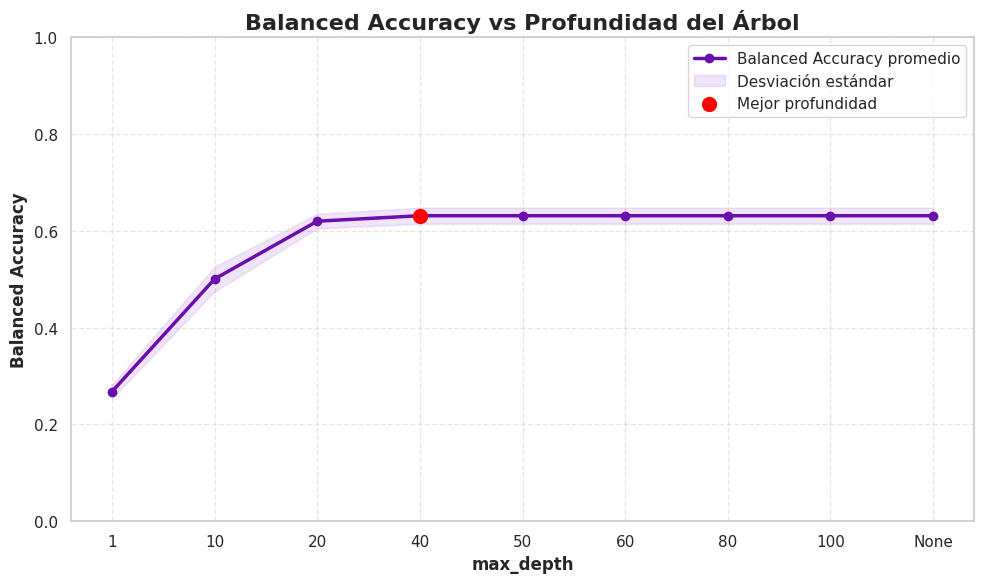

In [26]:

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"

df_plot = results_dt.copy()
df_plot["param_max_depth"] = df_plot["param_max_depth"].astype(str)

# Orden de profundidades
#orden_depth = ["1", "2", "3", "4", "5", "6", "8", "10", "12", "15", "20", "None"]
orden_depth = ["1", "10", "20", "40", "50", "60", "80", "100", "None"]
df_plot["param_max_depth"] = pd.Categorical(
    df_plot["param_max_depth"],
    categories=orden_depth,
    ordered=True
)
df_plot = df_plot.sort_values("param_max_depth")

plt.figure(figsize=(10, 6))

# Balanced accuracy promedio en validación
plt.plot(
    df_plot["param_max_depth"],
    df_plot["mean_test_score"],
    marker="o",
    linewidth=2.5,
    color="#6A0DAD",
    label="Balanced Accuracy promedio"
)

# Banda de desviación estándar
plt.fill_between(
    range(len(df_plot)),
    df_plot["mean_test_score"] - df_plot["std_test_score"],
    df_plot["mean_test_score"] + df_plot["std_test_score"],
    alpha=0.2,
    color="#B57EDC",
    label="Desviación estándar"
)

# Resaltar mejor punto
best_idx = df_plot["mean_test_score"].idxmax()
best_x = list(df_plot.index).index(best_idx)
best_y = df_plot.loc[best_idx, "mean_test_score"]

plt.scatter(best_x, best_y, color="red", s=100, zorder=5, label="Mejor profundidad")

plt.title("Balanced Accuracy vs Profundidad del Árbol", fontsize=16, fontweight="bold")
plt.xlabel("max_depth", fontsize=12, fontweight="bold")
plt.ylabel("Balanced Accuracy", fontsize=12, fontweight="bold")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [27]:
best_depth = grid_dt.best_params_["max_depth"]

best_dt = DecisionTreeClassifier(
    max_depth=best_depth,
    class_weight="balanced",
    random_state=42
)

acc_scores = []
bacc_scores = []
y_true_total = []
y_pred_total = []

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    best_dt.fit(X_train, y_train)
    y_pred = best_dt.predict(X_test)

    acc_scores.append(accuracy_score(y_test, y_pred))
    bacc_scores.append(balanced_accuracy_score(y_test, y_pred))

    y_true_total.extend(y_test)
    y_pred_total.extend(y_pred)

print("Resultados globales - Decision Tree")
print(f"Accuracy promedio: {np.mean(acc_scores):.4f}")
print(f"Desviación estándar Accuracy: {np.std(acc_scores):.4f}")
print(f"Balanced Accuracy promedio: {np.mean(bacc_scores):.4f}")
print(f"Desviación estándar Balanced Accuracy: {np.std(bacc_scores):.4f}")

Resultados globales - Decision Tree
Accuracy promedio: 0.6256
Desviación estándar Accuracy: 0.0165
Balanced Accuracy promedio: 0.6314
Desviación estándar Balanced Accuracy: 0.0165


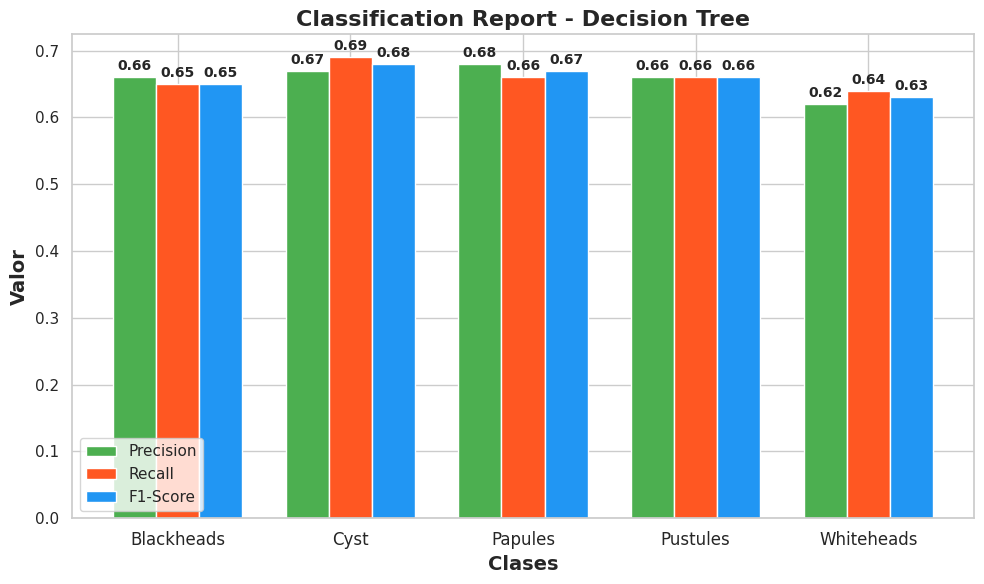

In [28]:
# Datos del classification report - Decision Tree
clases = ['Blackheads', 'Cyst', 'Papules', 'Pustules', 'Whiteheads']
precision = [0.66, 0.67, 0.68, 0.66, 0.62]
recall = [0.65, 0.69, 0.66, 0.66, 0.64]
f1_score = [0.65, 0.68, 0.67, 0.66, 0.63]

# Crear gráfico de barras
x = np.arange(len(clases))  # Las posiciones de las clases
width = 0.25  # El ancho de las barras

fig, ax = plt.subplots(figsize=(10, 6))

# Crear las barras para las tres métricas
rects1 = ax.bar(x - width, precision, width, label='Precision', color='#4CAF50')
rects2 = ax.bar(x, recall, width, label='Recall', color='#FF5722')
rects3 = ax.bar(x + width, f1_score, width, label='F1-Score', color='#2196F3')

# Añadir texto encima de las barras
for rect in rects1:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # Desplazar el texto
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

for rect in rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # Desplazar el texto
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

for rect in rects3:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # Desplazar el texto
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Personalización del gráfico
ax.set_xlabel('Clases', fontsize=14, fontweight='bold')
ax.set_ylabel('Valor', fontsize=14, fontweight='bold')
ax.set_title('Classification Report - Decision Tree', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(clases, fontsize=12)
ax.legend()

# Mostrar la gráfica
fig.tight_layout()
plt.show()

In [29]:
print("Classification Report - Decision Tree")
print(classification_report(y_true_total, y_pred_total, target_names=le.classes_))

Classification Report - Decision Tree
              precision    recall  f1-score   support

  Blackheads       0.62      0.63      0.62       735
        Cyst       0.64      0.62      0.63       645
     Papules       0.61      0.63      0.62       621
    Pustules       0.62      0.61      0.61       584
  Whiteheads       0.70      0.67      0.69       193

    accuracy                           0.63      2778
   macro avg       0.64      0.63      0.63      2778
weighted avg       0.63      0.63      0.63      2778



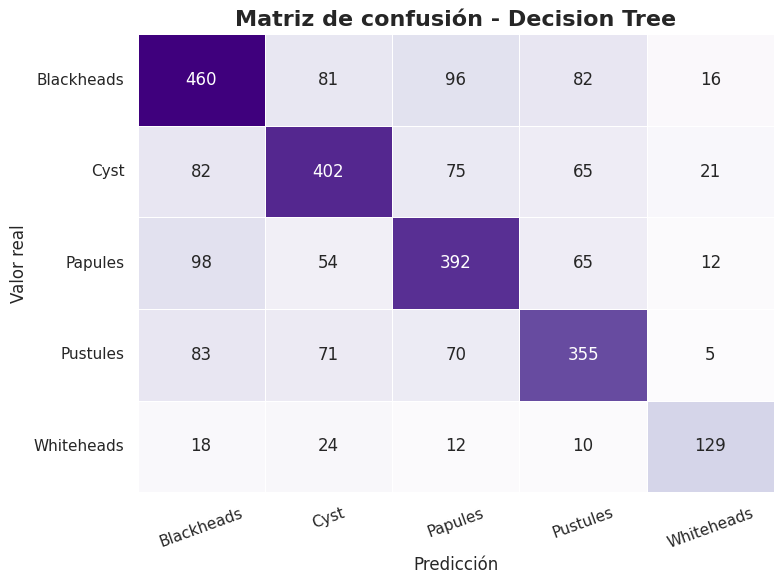

In [30]:
cm = confusion_matrix(y_true_total, y_pred_total)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Purples", cbar=False, linewidths=0.5)
plt.title("Matriz de confusión - Decision Tree", fontsize=16, fontweight="bold")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

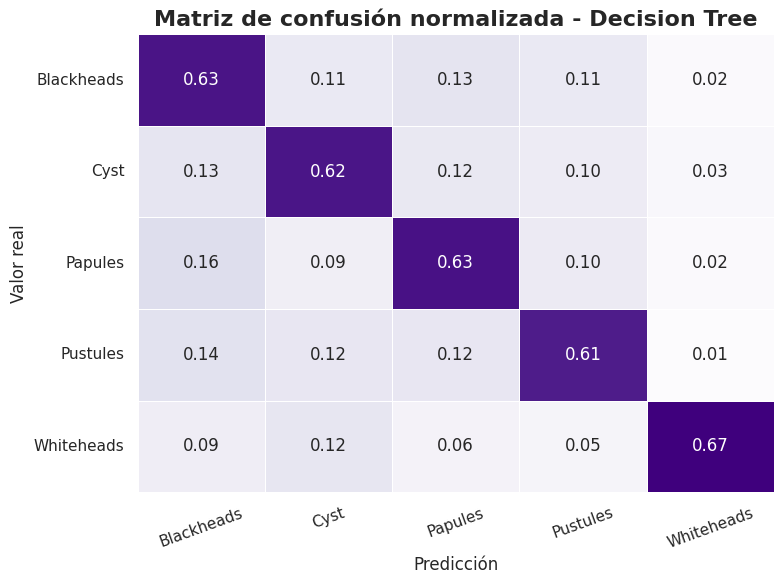

In [31]:
cm_norm = confusion_matrix(y_true_total, y_pred_total, normalize="true")
cm_norm_df = pd.DataFrame(cm_norm, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Purples", cbar=False, linewidths=0.5)
plt.title("Matriz de confusión normalizada - Decision Tree", fontsize=16, fontweight="bold")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#Random Forest:

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
import pandas as pd

# Validación cruzada estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Modelo base
rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Grid general
param_grid = {
    "n_estimators": [10, 15, 20, 50, 100],
    "max_depth": [1, 2, 5, 10, 15, 20]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=skf,
    scoring="balanced_accuracy",
    n_jobs=-1,
    return_train_score=True
)

grid_rf.fit(X, y)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(class_weight='balanced',
                                              n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [1, 2, 5, 10, 15, 20],
                         'n_estimators': [10, 15, 20, 50, 100]},
             return_train_score=True, scoring='balanced_accuracy')

In [42]:
print("Mejores hiperparámetros encontrados:")
print(grid_rf.best_params_)

print("\nMejor balanced accuracy:")
print(f"{grid_rf.best_score_:.4f}")

Mejores hiperparámetros encontrados:
{'max_depth': 20, 'n_estimators': 100}

Mejor balanced accuracy:
0.6754


In [43]:
results_rf = pd.DataFrame(grid_rf.cv_results_)

results_rf[[
    "param_n_estimators",
    "param_max_depth",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("mean_test_score", ascending=False).head(15)

,param_n_estimators,param_max_depth,mean_test_score,std_test_score,rank_test_score
29,100,20,0.675439,0.012731,1
28,50,20,0.672554,0.020117,2
23,50,15,0.669840,0.015362,3
24,100,15,0.666159,0.020900,4
27,20,20,0.656486,0.021920,5
26,15,20,0.653611,0.026253,6
22,20,15,0.651750,0.021951,7
25,10,20,0.648576,0.018092,8
21,15,15,0.642308,0.015336,9
20,10,15,0.628891,0.011101,10


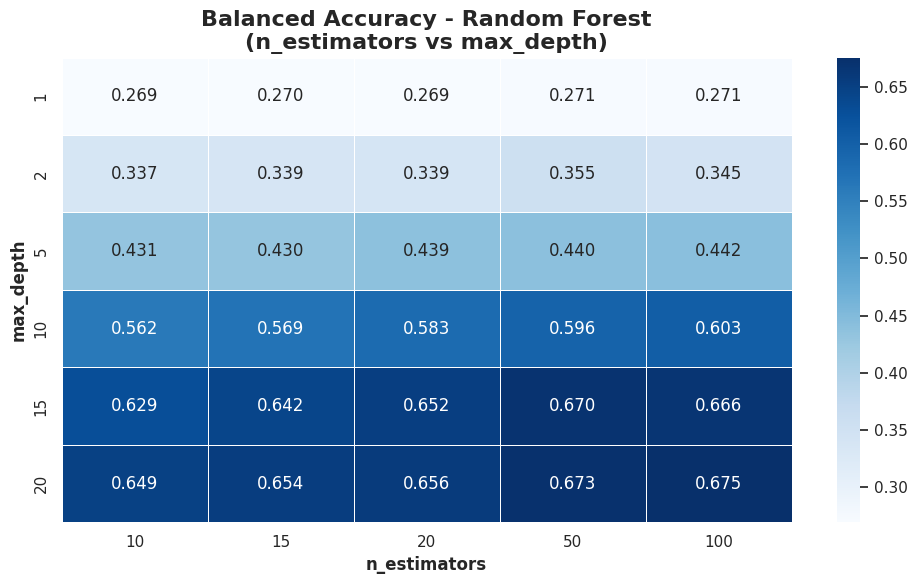

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"

df_heat = results_rf.copy()
df_heat["param_max_depth"] = df_heat["param_max_depth"].astype(str)

pivot_rf = df_heat.pivot_table(
    index="param_max_depth",
    columns="param_n_estimators",
    values="mean_test_score"
)

orden_depth = ["1", "2", "5", "10", "15", "20"]
pivot_rf = pivot_rf.reindex(orden_depth)

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_rf,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Balanced Accuracy - Random Forest\n(n_estimators vs max_depth)", fontsize=16, fontweight="bold")
plt.xlabel("n_estimators", fontsize=12, fontweight="bold")
plt.ylabel("max_depth", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

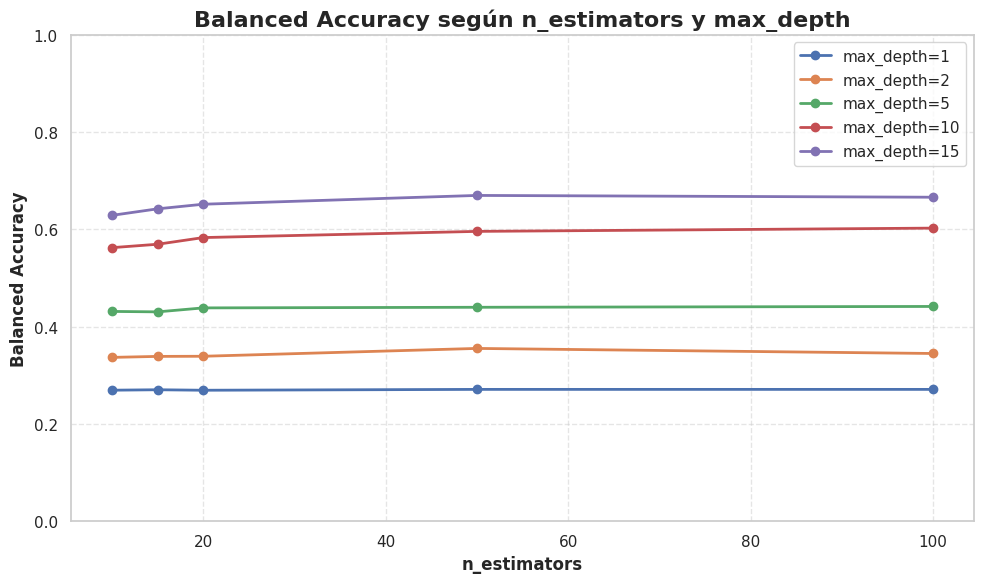

In [45]:
plt.figure(figsize=(10, 6))

df_lines = results_rf.copy()
df_lines["param_max_depth"] = df_lines["param_max_depth"].astype(str)

for depth in ["1", "2", "5", "10", "15"]:
    subset = df_lines[df_lines["param_max_depth"] == depth].sort_values("param_n_estimators")
    plt.plot(
        subset["param_n_estimators"],
        subset["mean_test_score"],
        marker="o",
        linewidth=2,
        label=f"max_depth={depth}"
    )

plt.title("Balanced Accuracy según n_estimators y max_depth", fontsize=16, fontweight="bold")
plt.xlabel("n_estimators", fontsize=12, fontweight="bold")
plt.ylabel("Balanced Accuracy", fontsize=12, fontweight="bold")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [46]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
import numpy as np

best_rf = RandomForestClassifier(
    **grid_rf.best_params_,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [47]:
acc_scores = []
bacc_scores = []
y_true_total = []
y_pred_total = []

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    best_rf.fit(X_train, y_train)
    y_pred = best_rf.predict(X_test)

    acc_scores.append(accuracy_score(y_test, y_pred))
    bacc_scores.append(balanced_accuracy_score(y_test, y_pred))

    y_true_total.extend(y_test)
    y_pred_total.extend(y_pred)

In [48]:
print("Resultados globales - Random Forest")
print(f"Accuracy promedio: {np.mean(acc_scores):.4f}")
print(f"Desviación estándar Accuracy: {np.std(acc_scores):.4f}")
print(f"Balanced Accuracy promedio: {np.mean(bacc_scores):.4f}")
print(f"Desviación estándar Balanced Accuracy: {np.std(bacc_scores):.4f}")

Resultados globales - Random Forest
Accuracy promedio: 0.6796
Desviación estándar Accuracy: 0.0118
Balanced Accuracy promedio: 0.6754
Desviación estándar Balanced Accuracy: 0.0127


In [49]:
print("Classification Report - Random Forest")
print(classification_report(y_true_total, y_pred_total, target_names=le.classes_))

Classification Report - Random Forest
              precision    recall  f1-score   support

  Blackheads       0.63      0.69      0.65       735
        Cyst       0.70      0.70      0.70       645
     Papules       0.67      0.67      0.67       621
    Pustules       0.69      0.67      0.68       584
  Whiteheads       0.89      0.65      0.75       193

    accuracy                           0.68      2778
   macro avg       0.72      0.68      0.69      2778
weighted avg       0.68      0.68      0.68      2778



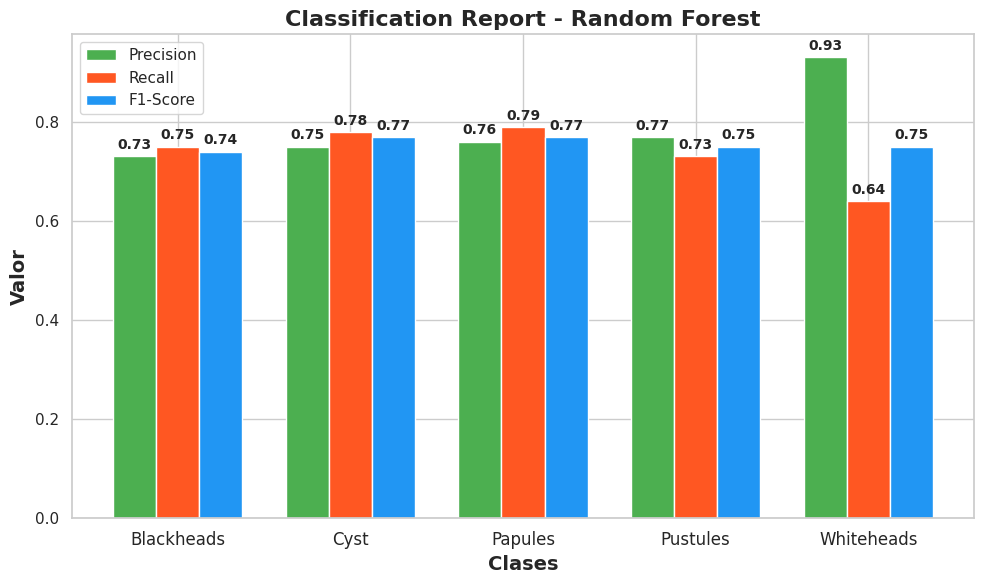

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# Datos del classification report - Random Forest
clases = ['Blackheads', 'Cyst', 'Papules', 'Pustules', 'Whiteheads']
precision = [0.73, 0.75, 0.76, 0.77, 0.93]
recall = [0.75, 0.78, 0.79, 0.73, 0.64]
f1_score = [0.74, 0.77, 0.77, 0.75, 0.75]

# Crear gráfico de barras
x = np.arange(len(clases))  # Las posiciones de las clases
width = 0.25  # El ancho de las barras

fig, ax = plt.subplots(figsize=(10, 6))

# Crear las barras para las tres métricas
rects1 = ax.bar(x - width, precision, width, label='Precision', color='#4CAF50')
rects2 = ax.bar(x, recall, width, label='Recall', color='#FF5722')
rects3 = ax.bar(x + width, f1_score, width, label='F1-Score', color='#2196F3')

# Añadir texto encima de las barras
for rect in rects1:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # Desplazar el texto
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

for rect in rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # Desplazar el texto
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

for rect in rects3:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # Desplazar el texto
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Personalización del gráfico
ax.set_xlabel('Clases', fontsize=14, fontweight='bold')
ax.set_ylabel('Valor', fontsize=14, fontweight='bold')
ax.set_title('Classification Report - Random Forest', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(clases, fontsize=12)
ax.legend()

# Mostrar la gráfica
fig.tight_layout()
plt.show()

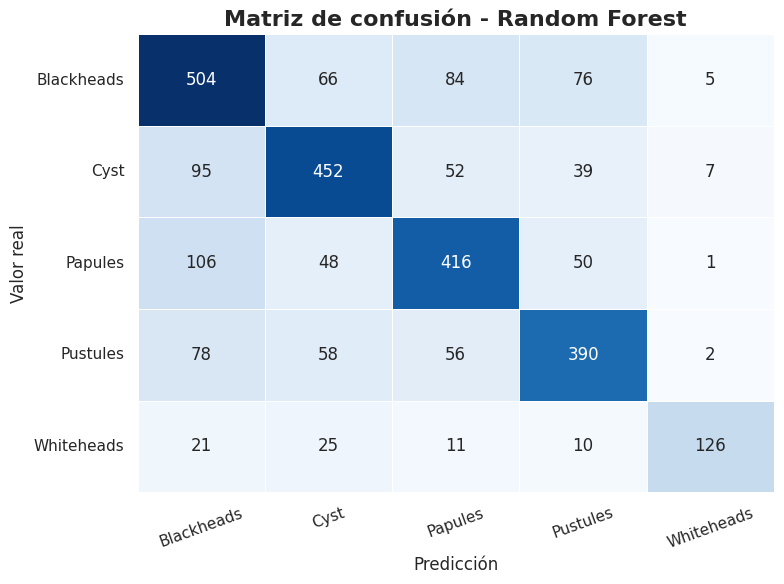

In [51]:
cm = confusion_matrix(y_true_total, y_pred_total)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=0.5)
plt.title("Matriz de confusión - Random Forest", fontsize=16, fontweight="bold")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

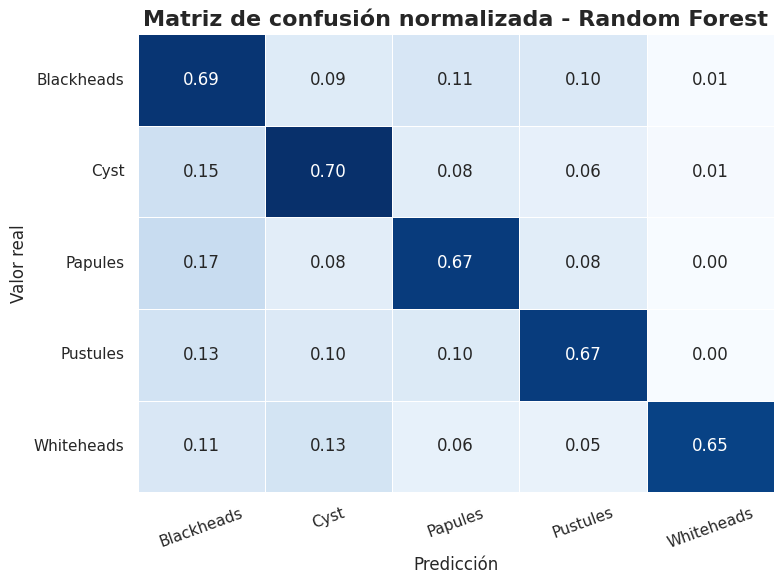

In [52]:
cm_norm = confusion_matrix(y_true_total, y_pred_total, normalize="true")
cm_norm_df = pd.DataFrame(cm_norm, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Blues", cbar=False, linewidths=0.5)
plt.title("Matriz de confusión normalizada - Random Forest", fontsize=16, fontweight="bold")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#SVM:

In [53]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd
import numpy as np

# Validación cruzada estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

kernels = ["linear", "poly", "rbf", "sigmoid"]

resultados_kernel = []

for k in kernels:
    model = SVC(
        kernel=k,
        C=1.0,
        class_weight="balanced",
        random_state=42
    )

    scores = cross_val_score(
        model,
        X,
        y,
        cv=skf,
        scoring="balanced_accuracy",
        n_jobs=-1
    )

    resultados_kernel.append({
        "Kernel": k,
        "Balanced_Accuracy_Mean": scores.mean(),
        "Balanced_Accuracy_Std": scores.std()
    })

df_kernels = pd.DataFrame(resultados_kernel)
df_kernels

,Kernel,Balanced_Accuracy_Mean,Balanced_Accuracy_Std
0,linear,0.378908,0.016347
1,poly,0.352602,0.029152
2,rbf,0.421955,0.016024
3,sigmoid,0.163438,0.014297


In [54]:
best_row = df_kernels.loc[df_kernels["Balanced_Accuracy_Mean"].idxmax()]
best_kernel = best_row["Kernel"]

print("Mejor kernel encontrado:", best_kernel)
print("Balanced Accuracy promedio:", round(best_row["Balanced_Accuracy_Mean"], 4))
print("Desviación estándar:", round(best_row["Balanced_Accuracy_Std"], 4))

Mejor kernel encontrado: rbf
Balanced Accuracy promedio: 0.422
Desviación estándar: 0.016


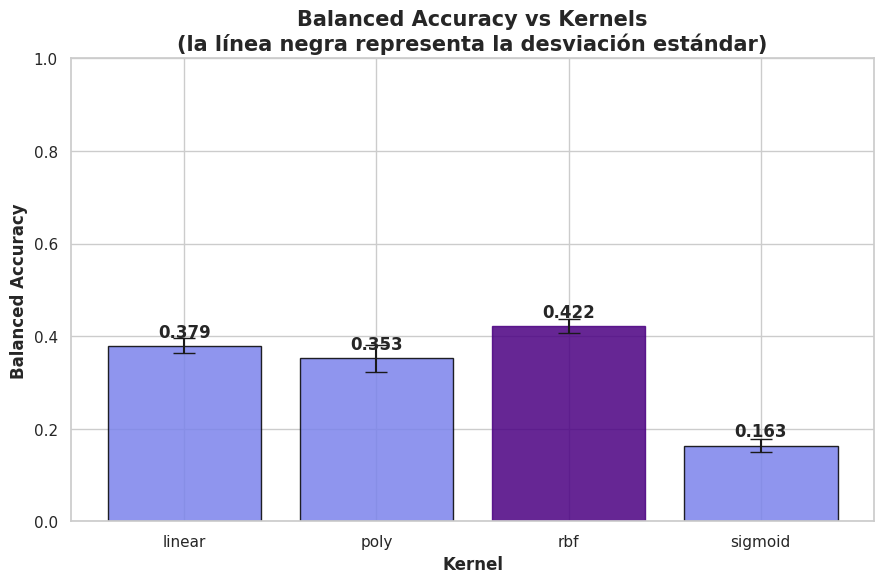

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"

plt.figure(figsize=(9, 6))

bars = plt.bar(
    df_kernels["Kernel"],
    df_kernels["Balanced_Accuracy_Mean"],
    yerr=df_kernels["Balanced_Accuracy_Std"],
    capsize=8,
    color="#7B83EB",
    edgecolor="black",
    alpha=0.85
)

# Resaltar mejor kernel
best_index = df_kernels["Balanced_Accuracy_Mean"].idxmax()
bars[list(df_kernels.index).index(best_index)].set_color("#4B0082")

plt.title("Balanced Accuracy vs Kernels\n(la línea negra representa la desviación estándar)", fontsize=15, fontweight="bold")
plt.xlabel("Kernel", fontsize=12, fontweight="bold")
plt.ylabel("Balanced Accuracy", fontsize=12, fontweight="bold")
plt.ylim(0, 1)

# Etiquetas encima de las barras
for i, row in df_kernels.iterrows():
    plt.text(
        i,
        row["Balanced_Accuracy_Mean"] + 0.02,
        f"{row['Balanced_Accuracy_Mean']:.3f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [56]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix

best_svm = SVC(
    kernel=best_kernel,
    C=1.0,
    class_weight="balanced",
    random_state=42
)

acc_scores = []
bacc_scores = []
y_true_total = []
y_pred_total = []

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    best_svm.fit(X_train, y_train)
    y_pred = best_svm.predict(X_test)

    acc_scores.append(accuracy_score(y_test, y_pred))
    bacc_scores.append(balanced_accuracy_score(y_test, y_pred))

    y_true_total.extend(y_test)
    y_pred_total.extend(y_pred)

In [57]:
print("Resultados globales - SVM")
print(f"Kernel seleccionado: {best_kernel}")
print(f"Accuracy promedio: {np.mean(acc_scores):.4f}")
print(f"Desviación estándar Accuracy: {np.std(acc_scores):.4f}")
print(f"Balanced Accuracy promedio: {np.mean(bacc_scores):.4f}")
print(f"Desviación estándar Balanced Accuracy: {np.std(bacc_scores):.4f}")

Resultados globales - SVM
Kernel seleccionado: rbf
Accuracy promedio: 0.4057
Desviación estándar Accuracy: 0.0110
Balanced Accuracy promedio: 0.4220
Desviación estándar Balanced Accuracy: 0.0160


In [58]:
print("Classification Report - SVM")
print(classification_report(y_true_total, y_pred_total, target_names=le.classes_))

Classification Report - SVM
              precision    recall  f1-score   support

  Blackheads       0.39      0.29      0.33       735
        Cyst       0.40      0.51      0.45       645
     Papules       0.41      0.50      0.45       621
    Pustules       0.36      0.30      0.33       584
  Whiteheads       0.54      0.51      0.52       193

    accuracy                           0.41      2778
   macro avg       0.42      0.42      0.42      2778
weighted avg       0.40      0.41      0.40      2778



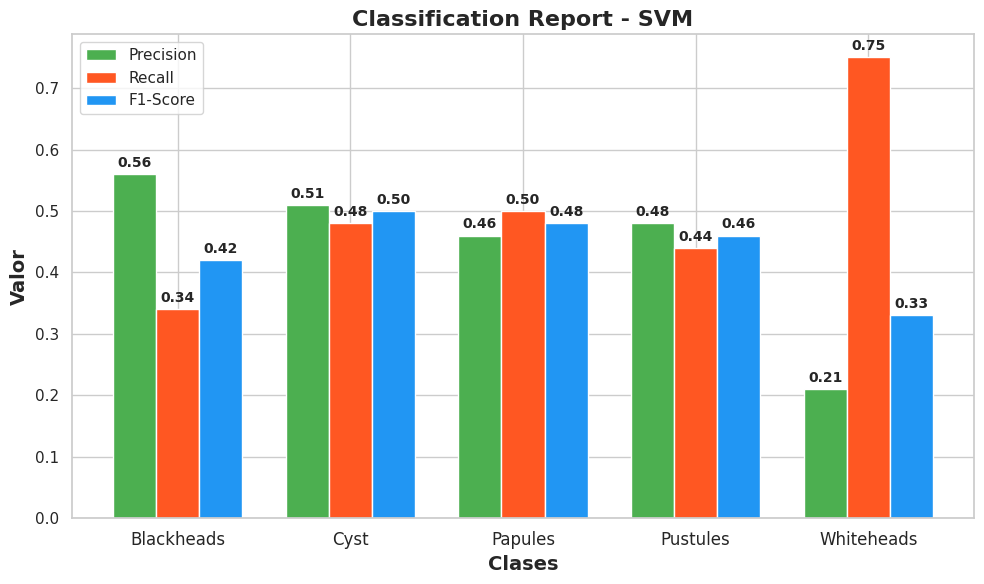

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Datos del classification report - SVM
clases = ['Blackheads', 'Cyst', 'Papules', 'Pustules', 'Whiteheads']
precision = [0.56, 0.51, 0.46, 0.48, 0.21]
recall = [0.34, 0.48, 0.50, 0.44, 0.75]
f1_score = [0.42, 0.50, 0.48, 0.46, 0.33]

# Crear gráfico de barras
x = np.arange(len(clases))  # Las posiciones de las clases
width = 0.25  # El ancho de las barras

fig, ax = plt.subplots(figsize=(10, 6))

# Crear las barras para las tres métricas
rects1 = ax.bar(x - width, precision, width, label='Precision', color='#4CAF50')
rects2 = ax.bar(x, recall, width, label='Recall', color='#FF5722')
rects3 = ax.bar(x + width, f1_score, width, label='F1-Score', color='#2196F3')

# Añadir texto encima de las barras
for rect in rects1:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # Desplazar el texto
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

for rect in rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # Desplazar el texto
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

for rect in rects3:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # Desplazar el texto
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Personalización del gráfico
ax.set_xlabel('Clases', fontsize=14, fontweight='bold')
ax.set_ylabel('Valor', fontsize=14, fontweight='bold')
ax.set_title('Classification Report - SVM', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(clases, fontsize=12)
ax.legend()

# Mostrar la gráfica
fig.tight_layout()
plt.show()

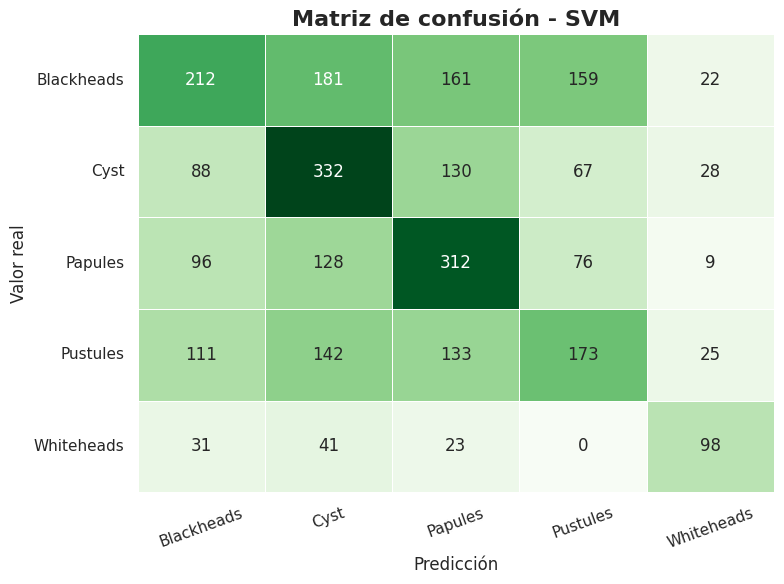

In [60]:
cm = confusion_matrix(y_true_total, y_pred_total)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Greens", cbar=False, linewidths=0.5)
plt.title("Matriz de confusión - SVM", fontsize=16, fontweight="bold")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()